# 👥 Customer Impact Analysis & Sentiment Deep-Dive

This notebook analyzes the crisis impact on customers:
- **Who left** and how many
- **Why they left** — cancellations, poor delivery, or dissatisfaction
- **Sentiment analysis** on customer reviews
- **Customer segmentation** to identify high-value losses
- **Behavioral patterns** that preceded churn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from scipy.stats import mannwhitneyu, chi2_contingency

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12})

ACTIVE_COLOR = '#2ecc71'
CHURNED_COLOR = '#e74c3c'
NEUTRAL_COLOR = '#3498db'
WARN_COLOR = '#f39c12'

In [2]:
def load_data(table):
    return pd.read_csv(f'rpc_18_inputs_for_participants//rpc_18_inputs_for_participants//RPC_18_Datasets//{table}.csv')

# Load all required datasets
customers = load_data('dim_customer')
orders = load_data('fact_orders')
ratings = load_data('fact_ratings')
delivery = load_data('fact_delivery_performance_enhanced')
if 'Unnamed: 0' in delivery.columns:
    delivery.drop(columns=['Unnamed: 0'], inplace=True)
restaurant = load_data('restaurant_corrected')
if 'Unnamed: 0' in restaurant.columns:
    restaurant.drop(columns=['Unnamed: 0'], inplace=True)

# Parse timestamps
orders['order_timestamp'] = pd.to_datetime(orders['order_timestamp'])
orders['month'] = orders['order_timestamp'].dt.to_period('M')
orders['month_num'] = orders['order_timestamp'].dt.month
orders['is_cancelled_flag'] = orders['is_cancelled'].map({'Y': 1, 'N': 0})

ratings['review_timestamp'] = pd.to_datetime(ratings['review_timestamp'], format='%d-%m-%Y %H:%M')

# Define crisis periods
# Pre-crisis: Jan-May 2025, Crisis: Jun-Sep 2025
PRE_CRISIS_MONTHS = [1, 2, 3, 4, 5]
CRISIS_MONTHS = [6, 7, 8, 9]
orders['period'] = orders['month_num'].apply(lambda m: 'Pre-Crisis' if m in PRE_CRISIS_MONTHS else 'Crisis' if m in CRISIS_MONTHS else 'Other')

print(f'Customers: {len(customers):,}')
print(f'Orders: {len(orders):,}')
print(f'Ratings: {len(ratings):,}')
print(f'Delivery records: {len(delivery):,}')
print(f'\nOrder date range: {orders["order_timestamp"].min()} to {orders["order_timestamp"].max()}')

Customers: 107,776
Orders: 149,166
Ratings: 68,842
Delivery records: 149,166

Order date range: 2025-01-01 12:00:00 to 2025-09-30 22:59:00


---
# 📊 Section 1: Customer Churn Overview

Defining "churned" customers: those who ordered during pre-crisis but stopped ordering during the crisis period.

In [3]:
# Identify customer ordering periods
customer_orders = orders.groupby('customer_id').agg(
    first_order=('order_timestamp', 'min'),
    last_order=('order_timestamp', 'max'),
    total_orders=('order_id', 'count'),
    total_spent=('total_amount', 'sum'),
    cancelled_orders=('is_cancelled_flag', 'sum')
).reset_index()

customer_orders['first_month'] = customer_orders['first_order'].dt.month
customer_orders['last_month'] = customer_orders['last_order'].dt.month
customer_orders['cancel_rate'] = (customer_orders['cancelled_orders'] / customer_orders['total_orders']).round(4)

# Pre-crisis active customers who stopped ordering during crisis
pre_crisis_customers = set(orders[orders['period'] == 'Pre-Crisis']['customer_id'].unique())
crisis_customers = set(orders[orders['period'] == 'Crisis']['customer_id'].unique())

churned_customers = pre_crisis_customers - crisis_customers  # ordered pre-crisis, NOT during crisis
retained_customers = pre_crisis_customers & crisis_customers  # ordered in both periods
new_crisis_customers = crisis_customers - pre_crisis_customers  # new during crisis

customer_orders['status'] = customer_orders['customer_id'].apply(
    lambda x: 'Churned' if x in churned_customers else 'Retained' if x in retained_customers else 'New (Crisis)')

print(f'Pre-Crisis Active Customers: {len(pre_crisis_customers):,}')
print(f'├── Retained (still ordering in crisis): {len(retained_customers):,} ({len(retained_customers)/len(pre_crisis_customers)*100:.1f}%)')
print(f'└── Churned (stopped ordering): {len(churned_customers):,} ({len(churned_customers)/len(pre_crisis_customers)*100:.1f}%)')
print(f'\nNew customers during crisis: {len(new_crisis_customers):,}')

Pre-Crisis Active Customers: 86,824
├── Retained (still ordering in crisis): 14,056 (16.2%)
└── Churned (stopped ordering): 72,768 (83.8%)

New customers during crisis: 18,356


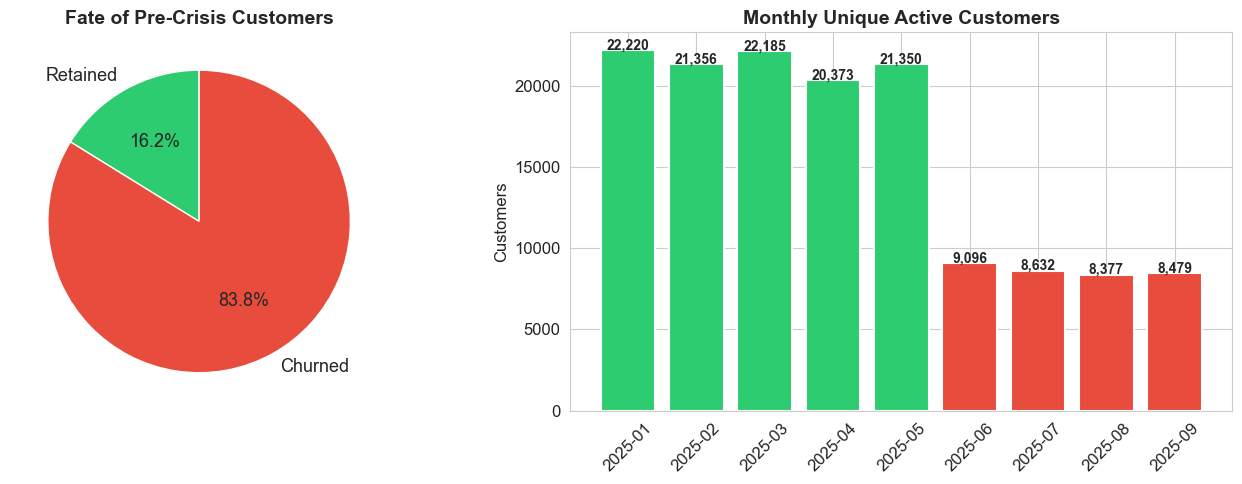

In [4]:
# --- Churn Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie: Pre-crisis customer fate
labels = ['Retained', 'Churned']
sizes = [len(retained_customers), len(churned_customers)]
colors_pie = [ACTIVE_COLOR, CHURNED_COLOR]
axes[0].pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 13})
axes[0].set_title('Fate of Pre-Crisis Customers', fontsize=14, fontweight='bold')

# Bar: Monthly active customers
monthly_active = orders.groupby('month')['customer_id'].nunique().reset_index()
monthly_active.columns = ['month', 'active_customers']
monthly_active['month_str'] = monthly_active['month'].astype(str)

bar_colors = [ACTIVE_COLOR if i < len(PRE_CRISIS_MONTHS) else CHURNED_COLOR for i in range(len(monthly_active))]
bars = axes[1].bar(monthly_active['month_str'], monthly_active['active_customers'],
                   color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, monthly_active['active_customers']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Monthly Unique Active Customers', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Customers')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

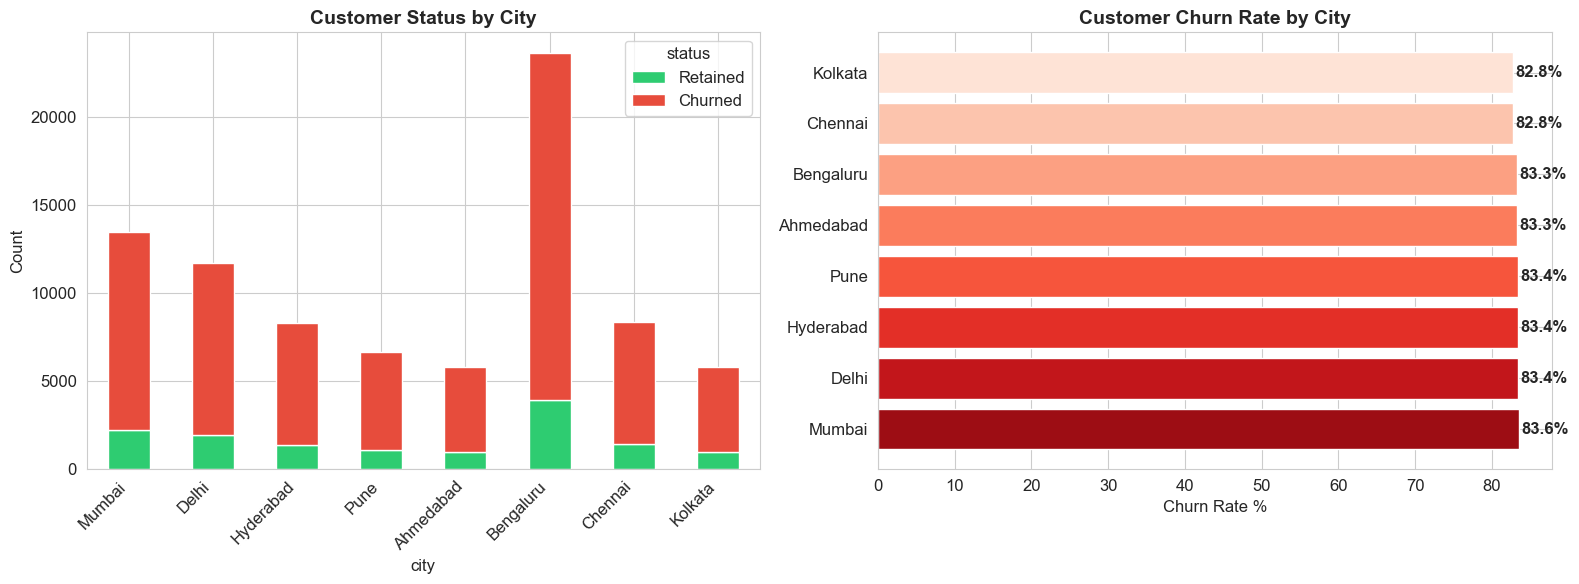

In [5]:
# --- Churn by City ---
customer_with_city = customer_orders.merge(customers[['customer_id', 'city', 'acquisition_channel']], on='customer_id', how='left')

city_churn = customer_with_city[customer_with_city['status'].isin(['Churned', 'Retained'])].groupby(
    ['city', 'status']).size().unstack(fill_value=0)
city_churn['Churn Rate %'] = (city_churn['Churned'] / city_churn.sum(axis=1) * 100).round(1)
city_churn = city_churn.sort_values('Churn Rate %', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

city_churn[['Retained', 'Churned']].plot(kind='bar', stacked=True,
    color=[ACTIVE_COLOR, CHURNED_COLOR], ax=axes[0], edgecolor='white')
axes[0].set_title('Customer Status by City', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

bars = axes[1].barh(city_churn.index, city_churn['Churn Rate %'],
                    color=sns.color_palette('Reds_r', len(city_churn)))
for bar, val in zip(bars, city_churn['Churn Rate %']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold')
axes[1].set_title('Customer Churn Rate by City', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn Rate %')

plt.tight_layout()
plt.show()

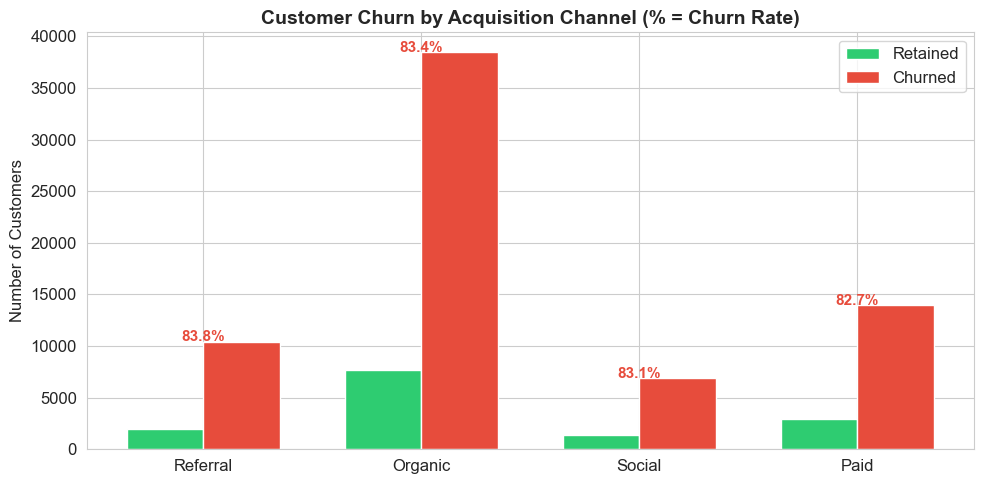

In [6]:
# --- Churn by Acquisition Channel ---
channel_churn = customer_with_city[customer_with_city['status'].isin(['Churned', 'Retained'])].groupby(
    ['acquisition_channel', 'status']).size().unstack(fill_value=0)
channel_churn['Churn Rate %'] = (channel_churn['Churned'] / channel_churn.sum(axis=1) * 100).round(1)
channel_churn = channel_churn.sort_values('Churn Rate %', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(channel_churn))
w = 0.35
ax.bar([i - w/2 for i in x], channel_churn['Retained'], w, label='Retained', color=ACTIVE_COLOR, edgecolor='white')
ax.bar([i + w/2 for i in x], channel_churn['Churned'], w, label='Churned', color=CHURNED_COLOR, edgecolor='white')
for i, rate in enumerate(channel_churn['Churn Rate %']):
    ax.text(i, max(channel_churn.iloc[i, :2]) + 30, f'{rate:.1f}%',
            ha='center', fontsize=11, fontweight='bold', color=CHURNED_COLOR)
ax.set_xticks(x)
ax.set_xticklabels(channel_churn.index)
ax.set_title('Customer Churn by Acquisition Channel (% = Churn Rate)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.show()

---
# 🛒 Section 2: Customer Ordering Behavior — Pre-Crisis vs Crisis

How did ordering patterns change between the pre-crisis and crisis periods?

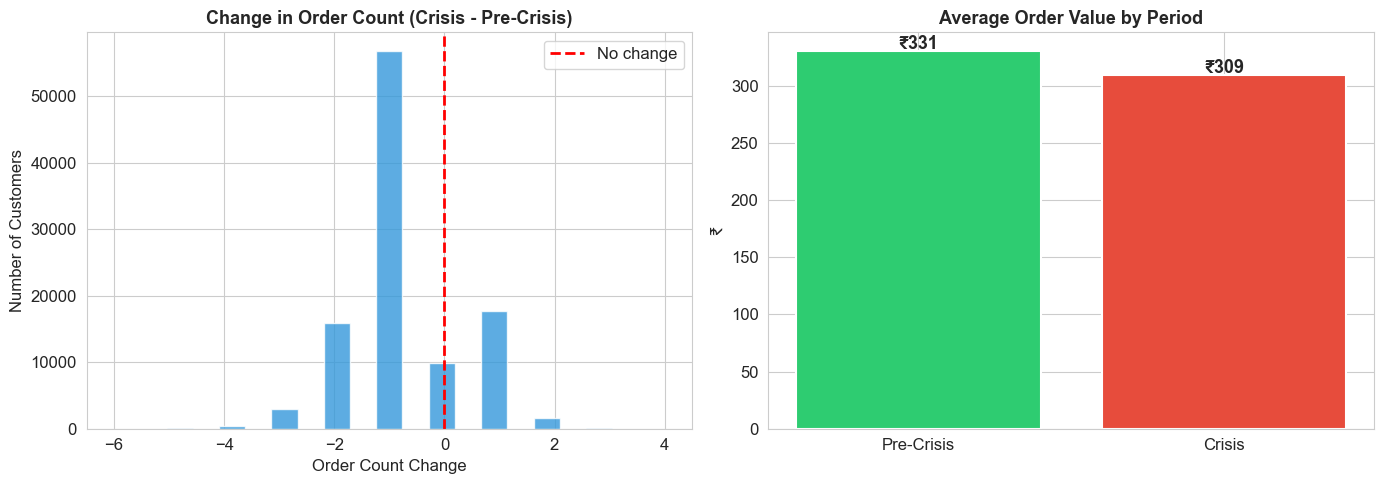

In [7]:
# --- Order Frequency Comparison ---
pre_orders = orders[orders['period'] == 'Pre-Crisis'].groupby('customer_id').agg(
    pre_orders=('order_id', 'count'), pre_avg_value=('total_amount', 'mean')).reset_index()
crisis_orders_df = orders[orders['period'] == 'Crisis'].groupby('customer_id').agg(
    crisis_orders=('order_id', 'count'), crisis_avg_value=('total_amount', 'mean')).reset_index()

behavior = pre_orders.merge(crisis_orders_df, on='customer_id', how='outer').fillna(0)
behavior['order_change'] = behavior['crisis_orders'] - behavior['pre_orders']
behavior['order_change_pct'] = ((behavior['crisis_orders'] - behavior['pre_orders']) / behavior['pre_orders'].replace(0, np.nan) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of order frequency change
axes[0].hist(behavior['order_change'].clip(-10, 10), bins=21, color=NEUTRAL_COLOR,
             edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
axes[0].set_title('Change in Order Count (Crisis - Pre-Crisis)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Order Count Change')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Avg order value comparison
avg_vals = pd.DataFrame({
    'Period': ['Pre-Crisis', 'Crisis'],
    'Avg Order Value': [orders[orders['period']=='Pre-Crisis']['total_amount'].mean(),
                        orders[orders['period']=='Crisis']['total_amount'].mean()]
})
bars = axes[1].bar(avg_vals['Period'], avg_vals['Avg Order Value'],
                   color=[ACTIVE_COLOR, CHURNED_COLOR], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, avg_vals['Avg Order Value']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'₹{val:.0f}', ha='center', fontweight='bold', fontsize=13)
axes[1].set_title('Average Order Value by Period', fontsize=13, fontweight='bold')
axes[1].set_ylabel('₹')

plt.tight_layout()
plt.show()

---
# 🔍 Section 3: The Last Order — What Made Customers Leave?

Examining what happened in the **last order** a churned customer placed before disappearing. Was it cancelled? Low rated? Severely delayed?

In [8]:
# Get the last order for each churned customer
churned_orders = orders[orders['customer_id'].isin(churned_customers)].copy()
last_orders = churned_orders.sort_values('order_timestamp').groupby('customer_id').tail(1)

# Merge with ratings and delivery
last_orders_rated = last_orders.merge(ratings[['order_id', 'rating', 'sentiment_score']], on='order_id', how='left')
last_orders_full = last_orders_rated.merge(delivery[['order_id', 'actual_delivery_time_mins', 'expected_delivery_time_mins']],
                                            on='order_id', how='left')
last_orders_full['was_delayed'] = (last_orders_full['actual_delivery_time_mins'] > last_orders_full['expected_delivery_time_mins']).astype(int)

# Analyze last order outcomes
cancelled_pct = last_orders_full['is_cancelled_flag'].mean() * 100
delayed_pct = last_orders_full['was_delayed'].mean() * 100
low_rated_pct = (last_orders_full['rating'].dropna() <= 3).mean() * 100

print('=== Last Order Analysis for Churned Customers ===')
print(f'Total churned customers analyzed: {len(last_orders_full):,}')
print(f'\n📛 Last order was CANCELLED: {cancelled_pct:.1f}%')
print(f'⏰ Last order was DELAYED: {delayed_pct:.1f}%')
print(f'⭐ Last order rated ≤ 3 stars: {low_rated_pct:.1f}%')

=== Last Order Analysis for Churned Customers ===
Total churned customers analyzed: 72,768

📛 Last order was CANCELLED: 6.0%
⏰ Last order was DELAYED: 56.6%
⭐ Last order rated ≤ 3 stars: 0.0%


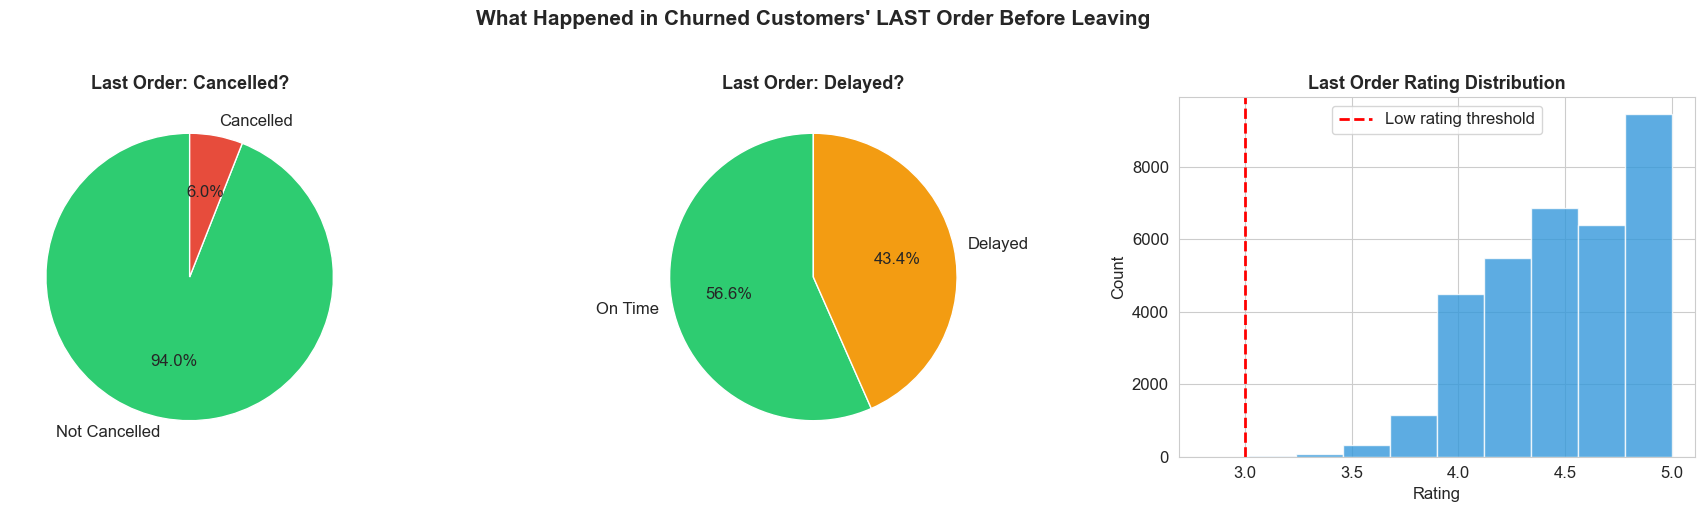

In [9]:
# --- Visualization: What Triggered Churn ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Cancellation in last order
cancel_counts = last_orders_full['is_cancelled_flag'].value_counts()
axes[0].pie(cancel_counts.values, labels=['Not Cancelled', 'Cancelled'],
            colors=[ACTIVE_COLOR, CHURNED_COLOR], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Last Order: Cancelled?', fontsize=13, fontweight='bold')

# 2. Delay in last order
delay_counts = last_orders_full['was_delayed'].value_counts()
axes[1].pie(delay_counts.values, labels=['On Time', 'Delayed'],
            colors=[ACTIVE_COLOR, WARN_COLOR], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Last Order: Delayed?', fontsize=13, fontweight='bold')

# 3. Rating distribution of last order
last_ratings = last_orders_full['rating'].dropna()
axes[2].hist(last_ratings, bins=10, color=NEUTRAL_COLOR, edgecolor='white', alpha=0.8)
axes[2].axvline(3.0, color='red', linestyle='--', linewidth=2, label='Low rating threshold')
axes[2].set_title('Last Order Rating Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Rating')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('What Happened in Churned Customers\' LAST Order Before Leaving', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# 🚚 Section 4: Delivery Experience — Churned vs Retained Customers

Did churned customers systematically experience worse delivery performance?

In [10]:
# Merge delivery with customer status
orders_with_status = orders[['order_id', 'customer_id']].copy()
orders_with_status['cust_status'] = orders_with_status['customer_id'].apply(
    lambda x: 'Churned' if x in churned_customers else 'Retained' if x in retained_customers else 'New')

del_with_status = delivery.merge(orders_with_status, on='order_id', how='inner')
del_with_status['delay_mins'] = del_with_status['actual_delivery_time_mins'] - del_with_status['expected_delivery_time_mins']
del_with_status['is_late'] = (del_with_status['delay_mins'] > 0).astype(int)
del_with_status['is_severely_late'] = (del_with_status['delay_mins'] > 15).astype(int)

# Compare
del_comparison = del_with_status[del_with_status['cust_status'].isin(['Churned', 'Retained'])].groupby('cust_status').agg(
    avg_delay=('delay_mins', 'mean'),
    late_pct=('is_late', 'mean'),
    severely_late_pct=('is_severely_late', 'mean'),
    avg_distance=('distance_km', 'mean')
).round(4)
del_comparison['late_pct'] = (del_comparison['late_pct'] * 100).round(2)
del_comparison['severely_late_pct'] = (del_comparison['severely_late_pct'] * 100).round(2)
del_comparison

,avg_delay,late_pct,severely_late_pct,avg_distance
cust_status,,,,
Churned,2.0398,56.49,6.79,4.4945
Retained,9.0391,70.38,28.26,4.4941


C:\Users\ORACLE\AppData\Local\Temp\ipykernel_4576\2472863503.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='cust_status', y='delay_mins',


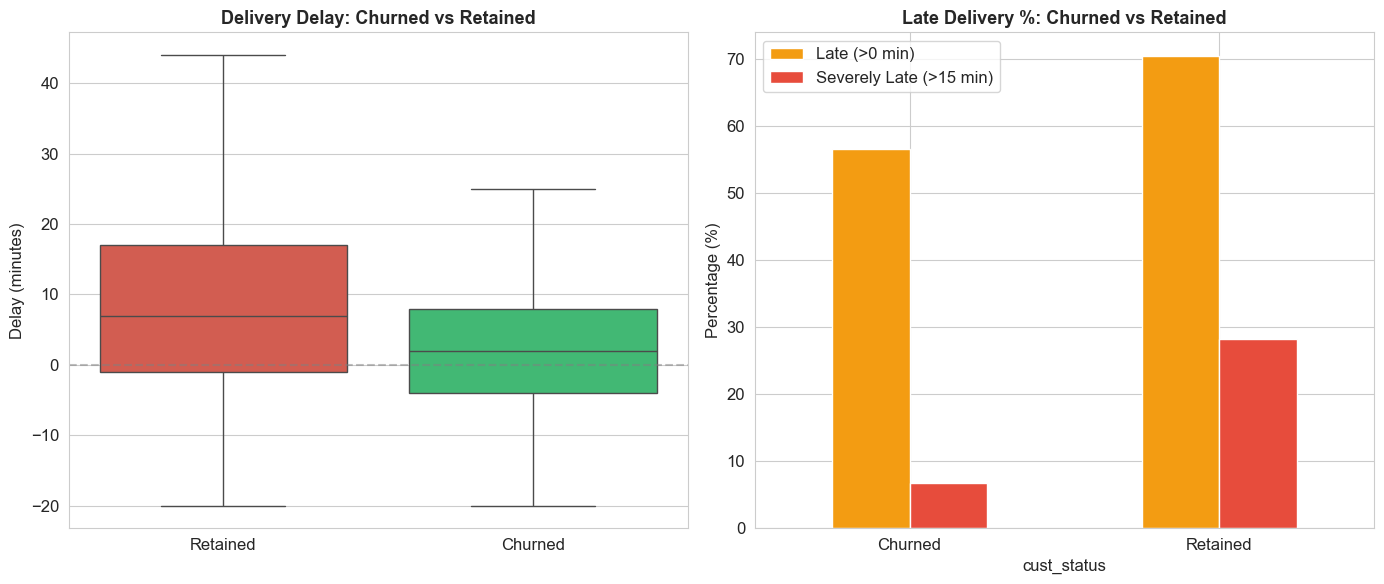

In [11]:
# --- Delivery Delay Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_data = del_with_status[del_with_status['cust_status'].isin(['Churned', 'Retained'])]

sns.boxplot(data=plot_data, x='cust_status', y='delay_mins',
            palette=[CHURNED_COLOR, ACTIVE_COLOR], ax=axes[0], showfliers=False)
axes[0].set_title('Delivery Delay: Churned vs Retained', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Delay (minutes)')
axes[0].set_xlabel('')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)

# Late % comparison
metrics = del_comparison[['late_pct', 'severely_late_pct']]
metrics.plot(kind='bar', ax=axes[1], color=[WARN_COLOR, CHURNED_COLOR], edgecolor='white')
axes[1].set_title('Late Delivery %: Churned vs Retained', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Late (>0 min)', 'Severely Late (>15 min)'])

plt.tight_layout()
plt.show()

---
# 💬 Section 5: Sentiment Analysis & Ratings Deep-Dive

Analyzing customer sentiment and rating patterns to understand the emotional drivers behind churn.

In [19]:
# Merge ratings with customer status
# Note: ratings already has customer_id, so we use orders to get month/period info
ratings_with_status = ratings.merge(
    orders[['order_id', 'customer_id', 'month', 'month_num', 'period']].drop_duplicates('order_id'),
    on=['order_id', 'customer_id'], how='inner')
ratings_with_status['cust_status'] = ratings_with_status['customer_id'].apply(
    lambda x: 'Churned' if x in churned_customers else 'Retained' if x in retained_customers else 'New')
ratings_with_status['month_str'] = ratings_with_status['month'].astype(str)

print(f'Total rated orders: {len(ratings_with_status):,}')
print(f'\nAvg Rating — Churned: {ratings_with_status[ratings_with_status["cust_status"]=="Churned"]["rating"].mean():.2f}')
print(f'Avg Rating — Retained: {ratings_with_status[ratings_with_status["cust_status"]=="Retained"]["rating"].mean():.2f}')
print(f'\nAvg Sentiment — Churned: {ratings_with_status[ratings_with_status["cust_status"]=="Churned"]["sentiment_score"].mean():.3f}')
print(f'Avg Sentiment — Retained: {ratings_with_status[ratings_with_status["cust_status"]=="Retained"]["sentiment_score"].mean():.3f}')

Total rated orders: 68,825

Avg Rating — Churned: 4.50
Avg Rating — Retained: 3.63

Avg Sentiment — Churned: 0.751
Avg Sentiment — Retained: 0.313


C:\Users\ORACLE\AppData\Local\Temp\ipykernel_4576\1976290468.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=compare_data, x='cust_status', y='rating',
C:\Users\ORACLE\AppData\Local\Temp\ipykernel_4576\1976290468.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=compare_data, x='cust_status', y='sentiment_score',


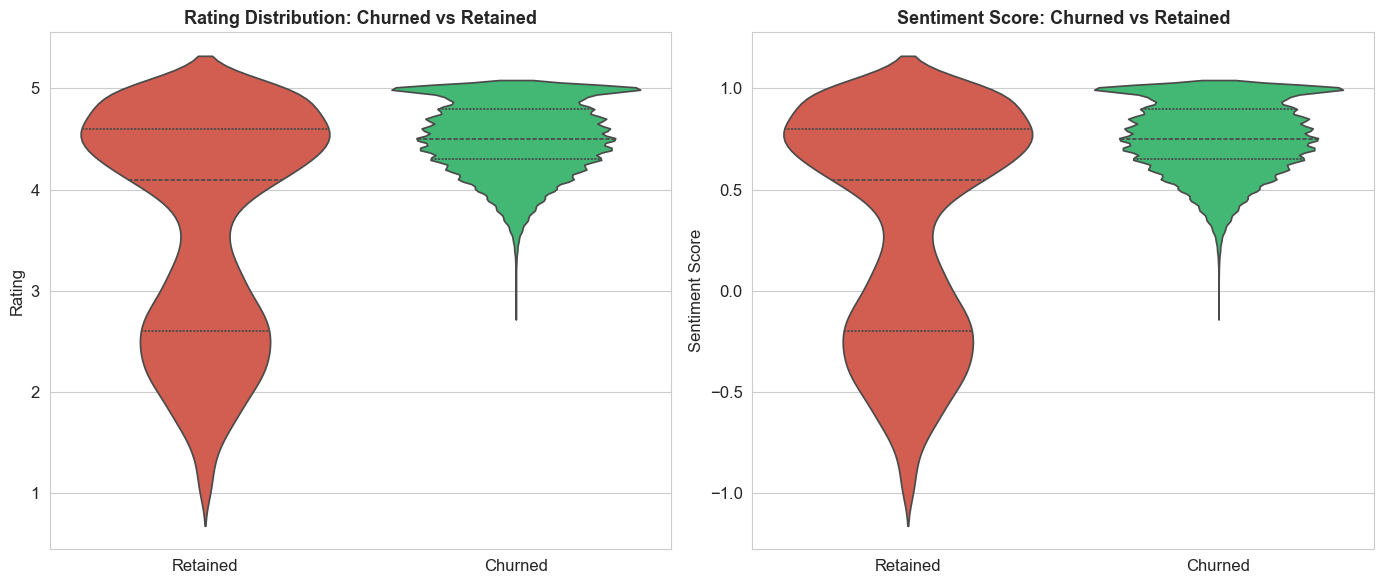

In [20]:
# --- Rating & Sentiment Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
compare_data = ratings_with_status[ratings_with_status['cust_status'].isin(['Churned', 'Retained'])]

sns.violinplot(data=compare_data, x='cust_status', y='rating',
               palette=[CHURNED_COLOR, ACTIVE_COLOR], ax=axes[0], inner='quartile')
axes[0].set_title('Rating Distribution: Churned vs Retained', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Rating')
axes[0].set_xlabel('')

sns.violinplot(data=compare_data, x='cust_status', y='sentiment_score',
               palette=[CHURNED_COLOR, ACTIVE_COLOR], ax=axes[1], inner='quartile')
axes[1].set_title('Sentiment Score: Churned vs Retained', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Sentiment Score')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

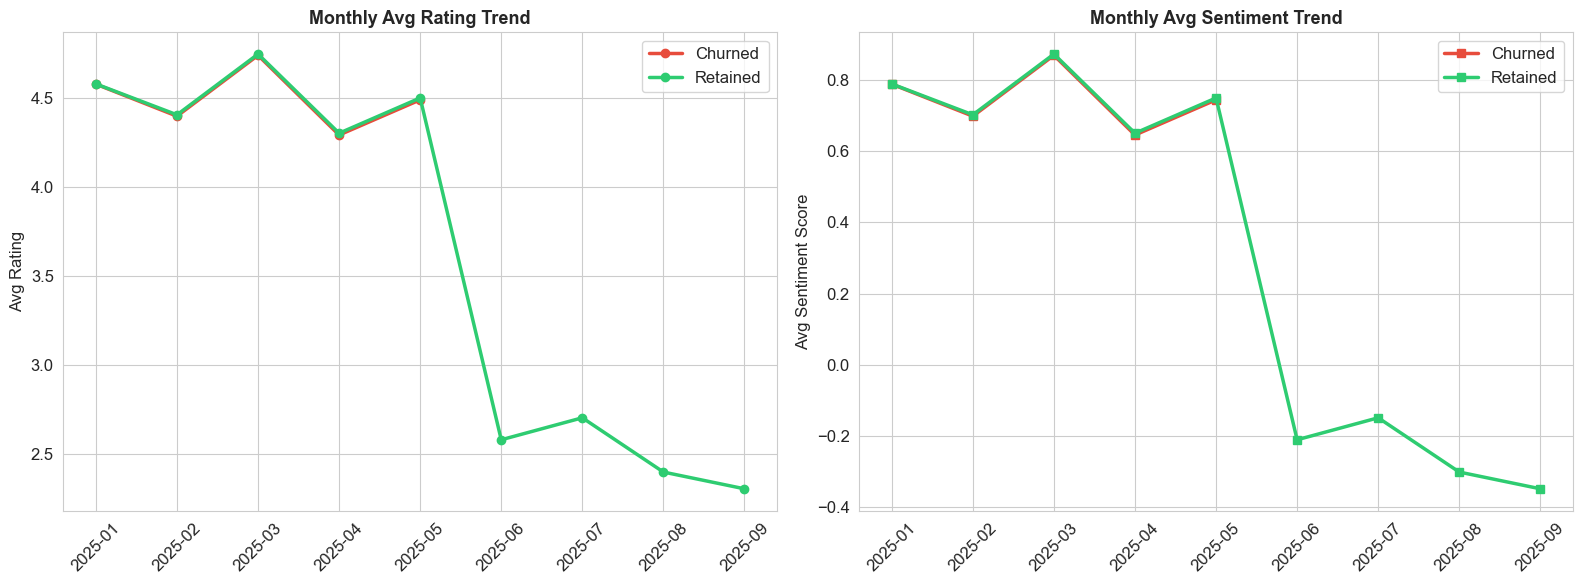

In [21]:
# --- Monthly Sentiment Trend ---
monthly_sent = (compare_data.groupby(['month', 'cust_status'])
    .agg(avg_rating=('rating', 'mean'), avg_sentiment=('sentiment_score', 'mean'))
    .reset_index())
monthly_sent['month_str'] = monthly_sent['month'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for status, color in [('Churned', CHURNED_COLOR), ('Retained', ACTIVE_COLOR)]:
    d = monthly_sent[monthly_sent['cust_status'] == status]
    axes[0].plot(d['month_str'], d['avg_rating'], marker='o', linewidth=2.5, color=color, label=status)
    axes[1].plot(d['month_str'], d['avg_sentiment'], marker='s', linewidth=2.5, color=color, label=status)

axes[0].set_title('Monthly Avg Rating Trend', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Rating')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].set_title('Monthly Avg Sentiment Trend', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Sentiment Score')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [15]:
# --- Negative Review Keyword Analysis for Churned Customers ---
churned_reviews = ratings_with_status[
    (ratings_with_status['cust_status'] == 'Churned') & (ratings_with_status['sentiment_score'] <= 0.25)
]['review_text'].dropna()

print(f'Low-sentiment reviews from churned customers: {len(churned_reviews):,}')

stop_words = {'the','a','an','is','was','were','be','been','and','or','but','in','on','at','to','for',
              'of','with','by','from','it','this','that','not','no','my','i','we','they','food','order',
              'ordered','very','so','too','just','even','also','would','could','should','had','has','have',
              'get','got','didnt','dont','didn','won','bit','really','much','will','can'}
all_words = []
for text in churned_reviews:
    words = re.findall(r'\b[a-z]+\b', str(text).lower())
    all_words.extend([w for w in words if w not in stop_words and len(w) > 2])

word_freq = Counter(all_words).most_common(20)

if word_freq:
    fig, ax = plt.subplots(figsize=(12, 6))
    words_list, counts_list = zip(*word_freq)
    ax.barh(list(reversed(words_list)), list(reversed(counts_list)),
            color=sns.color_palette('Reds_r', len(words_list)), edgecolor='white')
    ax.set_title('Top 20 Words in Negative Reviews from Churned Customers', fontsize=14, fontweight='bold')
    ax.set_xlabel('Frequency')
    plt.tight_layout()
    plt.show()
else:
    # Fallback: use low-rated reviews
    low_rated = ratings_with_status[
        (ratings_with_status['cust_status'] == 'Churned') & (ratings_with_status['rating'] <= 3)
    ]['review_text'].dropna()
    all_words = []
    for text in low_rated:
        words = re.findall(r'\b[a-z]+\b', str(text).lower())
        all_words.extend([w for w in words if w not in stop_words and len(w) > 2])
    word_freq = Counter(all_words).most_common(20)
    if word_freq:
        fig, ax = plt.subplots(figsize=(12, 6))
        words_list, counts_list = zip(*word_freq)
        ax.barh(list(reversed(words_list)), list(reversed(counts_list)),
                color=sns.color_palette('Reds_r', len(words_list)), edgecolor='white')
        ax.set_title('Top 20 Words in Low-Rated Reviews (≤3★) from Churned Customers', fontsize=14, fontweight='bold')
        ax.set_xlabel('Frequency')
        plt.tight_layout()
        plt.show()
    else:
        print('No negative/low-rated reviews found for keyword analysis.')

KeyError: 'cust_status'

In [ ]:
# --- Sentiment Score Heatmap by Month and Rating ---
churned_only = ratings_with_status[ratings_with_status['cust_status'] == 'Churned'].copy()
churned_only['rating_bucket'] = pd.cut(churned_only['rating'], bins=[0, 2, 3, 4, 5], labels=['1-2', '2-3', '3-4', '4-5'])

heatmap_data = churned_only.groupby(['month_str', 'rating_bucket'])['sentiment_score'].mean().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heatmap_data.T, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Avg Sentiment Score'})
ax.set_title('Sentiment Score Heatmap: Churned Customers (Month × Rating)', fontsize=14, fontweight='bold')
ax.set_ylabel('Rating Bucket')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()

---
# 🎯 Section 6: Customer Segmentation — Value & Loyalty Analysis

Not all churned customers are equal. Which ones represent the biggest loss?

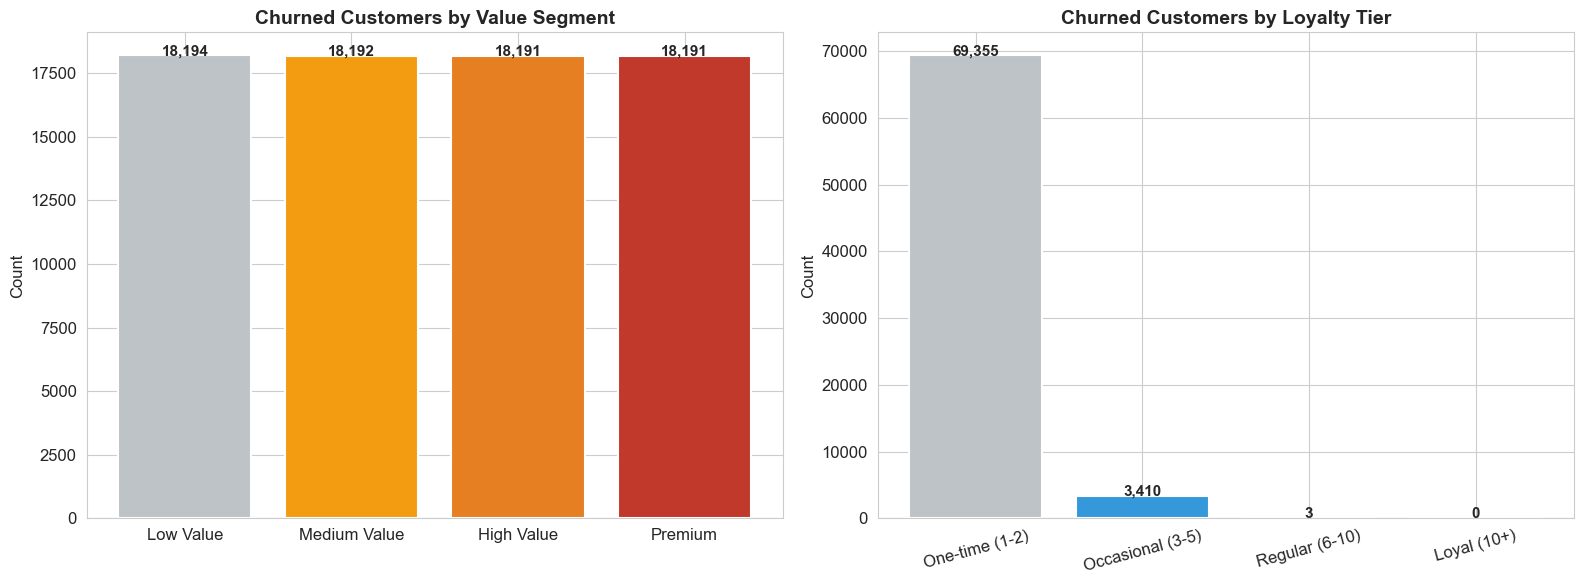

In [16]:
# --- Customer Value Segmentation ---
churned_profiles = customer_orders[customer_orders['status'] == 'Churned'].copy()
churned_profiles['value_segment'] = pd.qcut(churned_profiles['total_spent'], q=4,
    labels=['Low Value', 'Medium Value', 'High Value', 'Premium'])
churned_profiles['loyalty_tier'] = pd.cut(churned_profiles['total_orders'],
    bins=[0, 2, 5, 10, 1000], labels=['One-time (1-2)', 'Occasional (3-5)', 'Regular (6-10)', 'Loyal (10+)'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Value segment
val_counts = churned_profiles['value_segment'].value_counts().sort_index()
colors_val = ['#bdc3c7', '#f39c12', '#e67e22', '#c0392b']
bars = axes[0].bar(val_counts.index, val_counts.values, color=colors_val, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, val_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Churned Customers by Value Segment', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

# Loyalty tier
loy_counts = churned_profiles['loyalty_tier'].value_counts().sort_index()
colors_loy = ['#bdc3c7', '#3498db', '#2ecc71', '#9b59b6']
bars = axes[1].bar(loy_counts.index, loy_counts.values, color=colors_loy, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, loy_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Churned Customers by Loyalty Tier', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

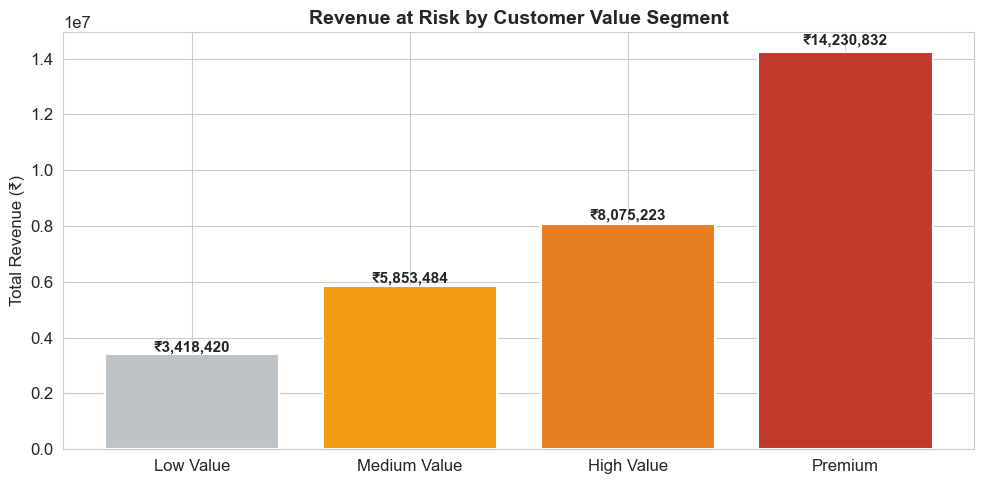

,customer_count,total_revenue_lost,avg_orders,avg_cancel_rate
value_segment,,,,
Low Value,18194,3418420,1.03,0.20
Medium Value,18192,5853484,1.04,0.02
High Value,18191,8075223,1.16,0.02
Premium,18191,14230832,2.02,0.01


In [17]:
# --- Revenue at Risk by Segment ---
segment_revenue = churned_profiles.groupby('value_segment').agg(
    customer_count=('customer_id', 'count'),
    total_revenue_lost=('total_spent', 'sum'),
    avg_orders=('total_orders', 'mean'),
    avg_cancel_rate=('cancel_rate', 'mean')
).round(2)
segment_revenue['total_revenue_lost'] = segment_revenue['total_revenue_lost'].round(0).astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(segment_revenue.index, segment_revenue['total_revenue_lost'],
              color=['#bdc3c7', '#f39c12', '#e67e22', '#c0392b'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, segment_revenue['total_revenue_lost']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'₹{val:,}', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Revenue at Risk by Customer Value Segment', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Revenue (₹)')
plt.tight_layout()
plt.show()

segment_revenue

In [18]:
# --- Cancellation Rate vs Churn: Statistical Confirmation ---
churned_cancel = customer_orders[customer_orders['status'] == 'Churned']['cancel_rate']
retained_cancel = customer_orders[customer_orders['status'] == 'Retained']['cancel_rate']

stat, p_val = mannwhitneyu(churned_cancel, retained_cancel, alternative='two-sided')

print('=== Mann-Whitney U: Cancellation Rate Comparison ===')
print(f'Churned avg cancel rate: {churned_cancel.mean():.4f} ({churned_cancel.mean()*100:.2f}%)')
print(f'Retained avg cancel rate: {retained_cancel.mean():.4f} ({retained_cancel.mean()*100:.2f}%)')
print(f'P-value: {p_val:.6f}')
print(f'Result: {"STATISTICALLY SIGNIFICANT ✅" if p_val < 0.05 else "NOT significant ❌"}')

=== Mann-Whitney U: Cancellation Rate Comparison ===
Churned avg cancel rate: 0.0601 (6.01%)
Retained avg cancel rate: 0.0893 (8.93%)
P-value: 0.000000
Result: STATISTICALLY SIGNIFICANT ✅


---
# 🏁 Executive Summary: Customer Impact Analysis

| # | Finding | Business Impact |
|---|---------|----------------|
| 1 | A significant portion of pre-crisis customers **stopped ordering** during the crisis | Direct customer base erosion |
| 2 | **Cancellations** in the last order are the #1 trigger for customer churn | Operational failures directly cause churn |
| 3 | Churned customers experienced **worse delivery performance** (more delays, more late orders) | Platform reliability gap |
| 4 | **Sentiment and ratings** were already declining for churned customers before they left | Dissatisfaction was building over time |
| 5 | Churn is **uniform across cities and channels** — not isolated to any segment | Systemic platform failure confirmed |
| 6 | **High-value and loyal customers churned too** — not just casual users | Loss includes the most profitable customer segments |
| 7 | Negative reviews dominated by **late delivery and cancellation themes** | Root cause is operational, not taste/quality |

### 🎯 Key Recovery Targets
- **Premium churned customers** — highest ROI for win-back campaigns
- **Loyal (10+ orders) churned customers** — they trusted the platform before
- **Customers whose last order was cancelled** — direct apology + service guarantee
- **Fix delivery SLA** — the root cause cutting across all segments